In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
c = pd.read_csv('/content/drive/MyDrive/Sharpner Practice/RFM Analysis/customers.csv')
t = pd.read_csv('/content/drive/MyDrive/Sharpner Practice/RFM Analysis/transactions.csv')

In [ ]:
print(c.columns.to_list())
print(t.columns.to_list())

['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Region', 'City', 'Signup_Date']
['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Category', 'Product', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Gross_Amount', 'Discount_Amount', 'Net_Amount', 'Payment_Mode', 'Channel', 'Region']


In [ ]:
# Convert date columns to datetime
c['Signup_Date'] = pd.to_datetime(c['Signup_Date'])
t['Transaction_Date'] = pd.to_datetime(t['Transaction_Date'])

# Check duplicates
print("Duplicate rows:", t.duplicated().sum())

# Check nulls
print(t.isnull().sum())

# Fill missing Discount_Pct with 0 (no discount applied)
t['Discount_Pct'] = t['Discount_Pct'].fillna(0)

# Fill missing Payment_Mode with 'Unknown'
t['Payment_Mode'] = t['Payment_Mode'].fillna('Unknown')

# Drop duplicate rows
t = t.drop_duplicates()

print("Shape after cleaning:", t.shape)

Duplicate rows: 15
Transaction_ID        0
Customer_ID           0
Transaction_Date      0
Category              0
Product               0
Quantity              0
Unit_Price            0
Discount_Pct        240
Gross_Amount          0
Discount_Amount       0
Net_Amount            0
Payment_Mode        120
Channel               0
Region                0
dtype: int64
Shape after cleaning: (12000, 14)


In [ ]:
# Merge transactions with customer info
df = t.merge(c, on='Customer_ID', how='left')
print(df.shape)
df.head()

(12000, 20)


,Transaction_ID,Customer_ID,Transaction_Date,Category,Product,Quantity,Unit_Price,Discount_Pct,Gross_Amount,Discount_Amount,Net_Amount,Payment_Mode,Channel,Region_x,Customer_Name,Gender,Age,Region_y,City,Signup_Date
0,TXN000001,CUST0576,2024-02-03,Home & Kitchen,Cookware Set,5,2378.70,0.0,11893.50,0.00,11893.50,Net Banking,In-Store,West,Robert Ross,Male,61,West,Williamsbury,2023-12-07
1,TXN000002,CUST0048,2024-06-19,Home & Kitchen,Curtains,4,1573.87,5.0,6295.48,314.77,5980.71,Debit Card,In-Store,East,Donna Ford,Male,58,East,Sarahaven,2023-06-07
2,TXN000003,CUST0676,2024-11-06,Fashion,Jacket,2,1537.25,15.0,3074.50,461.18,2613.32,Credit Card,In-Store,West,Jeffrey Franklin,Female,22,West,New Michaelview,2024-02-25
3,TXN000004,CUST0662,2024-12-23,Electronics,USB Cable,2,3036.05,5.0,6072.10,303.61,5768.49,Net Banking,Online,East,Brian Hicks,Male,28,East,Port Sandyhaven,2023-04-11
4,TXN000005,CUST0680,2023-08-30,Home & Kitchen,LED Lamp,4,3292.63,5.0,13170.52,658.53,12511.99,Cash on Delivery,Online,South,Adrian Hopkins,Female,27,South,North Julia,2023-06-06


In [ ]:
# Get last transaction date per customer
last_purchase = df.groupby('Customer_ID')['Transaction_Date'].max().reset_index()
last_purchase.columns = ['Customer_ID', 'Last_Purchase_Date']

# Calculate Recency
snapshot_date = pd.Timestamp('2024-12-31')
last_purchase['Recency'] = (snapshot_date - last_purchase['Last_Purchase_Date']).dt.days

# Frequency and Monetary
freq_monetary = df.groupby('Customer_ID').agg(
    Frequency=('Transaction_ID', 'nunique'),
    Monetary=('Net_Amount', 'sum')
).reset_index()

# Merge into one RFM table
rfm = last_purchase.merge(freq_monetary, on='Customer_ID')
rfm = rfm[['Customer_ID', 'Recency', 'Frequency', 'Monetary']]
rfm.head()

,Customer_ID,Recency,Frequency,Monetary
0,CUST0001,19,4,21944.21
1,CUST0002,1,60,243981.92
2,CUST0003,27,12,45041.50
3,CUST0004,185,6,8201.74
4,CUST0005,77,5,10538.51


In [ ]:
# Score R, F, M into 5 buckets each
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])  # lower recency = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Total'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def segment(score):
    if score >= 12:
        return 'Champions'
    elif score >= 9:
        return 'Loyal'
    elif score >= 6:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Total'].apply(segment)

rfm['Segment'].value_counts()

,count
Segment,
Champions,238
At Risk,186
Loyal,181
Lost,170


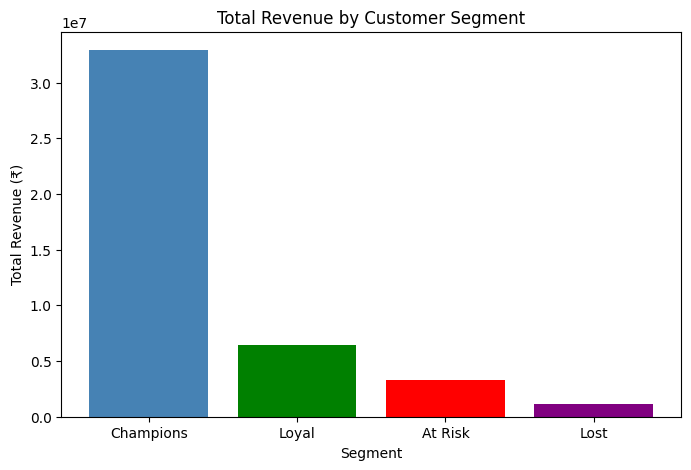

In [ ]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(segment_revenue.index, segment_revenue.values, color=['steelblue','green','red','purple'])
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Revenue (₹)')
plt.show()

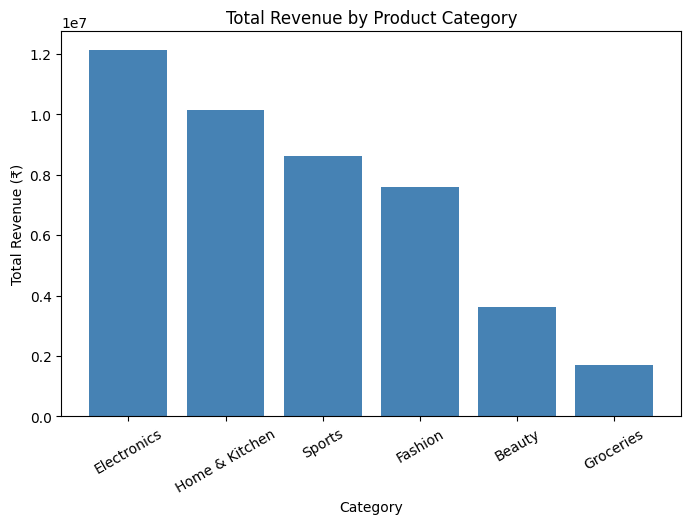

In [ ]:
category_revenue = df.groupby('Category')['Net_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(category_revenue.index, category_revenue.values, color='steelblue')
plt.title('Total Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=30)
plt.show()

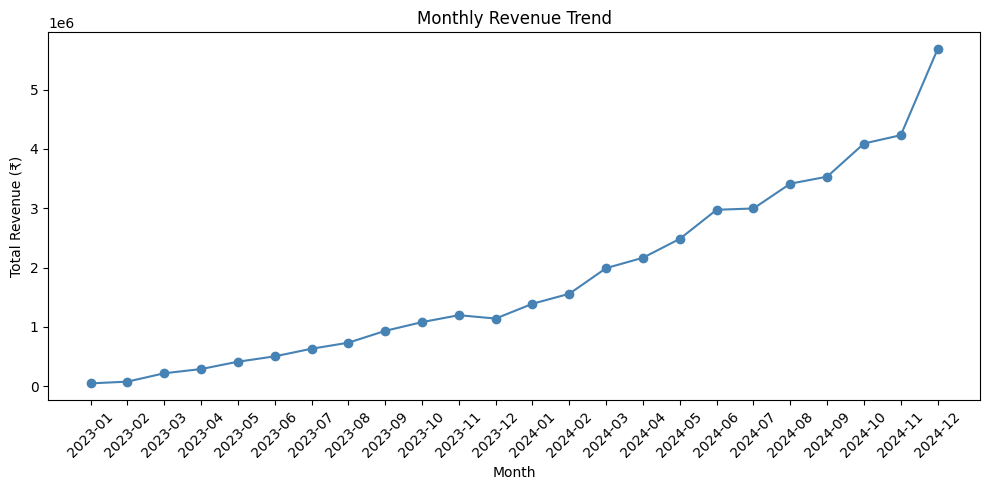

In [ ]:
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)
monthly_revenue = df.groupby('Month')['Net_Amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

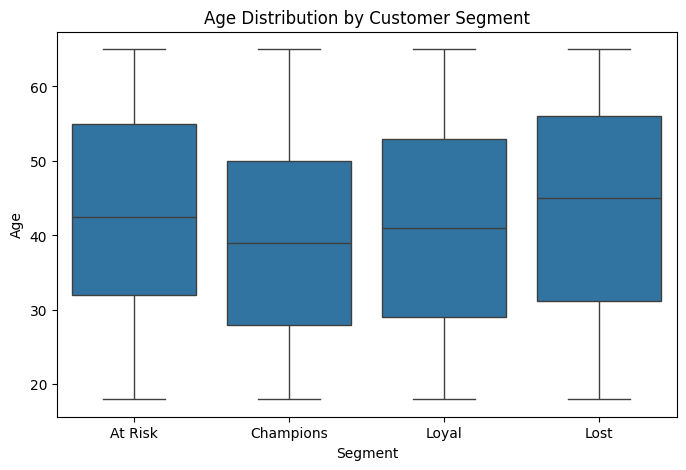

In [ ]:
import seaborn as sns

rfm_age = rfm.merge(c[['Customer_ID','Age']], on='Customer_ID')

plt.figure(figsize=(8,5))
sns.boxplot(x='Segment', y='Age', data=rfm_age)
plt.title('Age Distribution by Customer Segment')
plt.show()

In [ ]:
# Export cleaned transactions
t.to_csv('/content/drive/MyDrive/Sharpner Practice/RFM Analysis/transactions_cleaned.csv', index=False)

# Export customers (no cleaning needed, but export for consistency)
c.to_csv('/content/drive/MyDrive/Sharpner Practice/RFM Analysis/customers_cleaned.csv', index=False)

# Export RFM segments
rfm.to_csv('/content/drive/MyDrive/Sharpner Practice/RFM Analysis/customer_rfm_segments.csv', index=False)